Try to plot first 3 PCs or UMAP to see structure in NR isa vs nisa

In [1]:
# to avoid OpenBLAS error
import os
os.environ["OPENBLAS_NUM_THREADS"] = "48"

In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import fmatoolbox as fma
import regions as rg
import sklearn
import ISRUtilities as isru
import xarray as xr
import pathlib
froot = pathlib.Path().cwd().parent.parent / 'Results/Figures/ISAUnits'
batch_file = '/mnt/hubel-data-103/Pietro/InfraSlowNRPaper/Data/IS_intervals.batch'
do_save = False

In [4]:
def _regionPETH(session,reg=None,when=None,window=None,step=None):

    # load data
    R = rg.data.Regions(session,states='sws',events='InfraSlowRhythm/infraslowaval',phases=when)
    #regs = R.ids if regs is None else np.asarray(regs)[np.isin(regs,R.ids)]
    fr = R.unitFiringRate(regs=reg,when=when,window=window,step=step)
    _, is_isa = fma.general.restrict(fr,R.eventIntervals('slownr'),s_ind=True)

    clf = sklearn.linear_model.LogisticRegression(max_iter=500)
    out = sklearn.model_selection.cross_val_score(clf, fr[:,1:], is_isa, cv=5)

    #pipe = sklearn.pipeline.Pipeline([#('scaler', sklearn.preprocessing.StandardScaler()),
    #                                  ('pca', sklearn.decomposition.PCA(n_components=50)),
    #                                  ('t-SNE', sklearn.manifold.TSNE(n_components=3,verbose=2))])
    #out = pipe.fit_transform(fr[:,1:])

    #peth_oscill = xr.DataArray(out,dims=['name','tran','t'],coords={'name': names, 'tran': ['off_on','on_off'], 't': t, 'rat': int(R.rat)})

    return out, is_isa, R.firingRate(regs=reg,when=when,window=window,step=step,norm=True)

In [10]:
# test on one session
session = fma.data.readBatchFile(batch_file)[0][10]
print(session)
pca, is_isa, fr = _regionPETH(session,reg='pfc',when='sleep.*#0',window=0.2)

/mnt/hubel-data-139/perceval/Rat003_20231226/Rat003_20231226.xml


In [11]:
np.where(is_isa), pca

((array([ 8449,  8450,  8451, ..., 35067, 35068, 35069], shape=(13610,)),),
 array([0.81183331, 0.82363817, 0.79377045, 0.67045939, 0.54188593]))

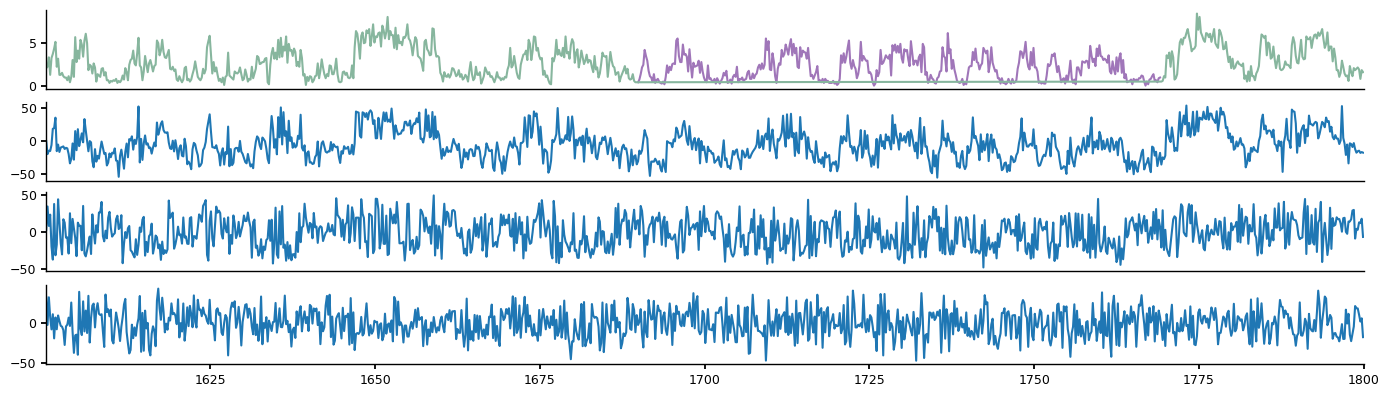

In [11]:
fig, ax = fma.plotting.makeFigure(n=[4,1],size=(35,10))
start = 8000
stop = start + 1000
fma.plotting.plotXY(fr[start:stop][is_isa[start:stop]],ax=ax[0],color=isru.paperColors('nr'))
fma.plotting.plotXY(fr[start:stop][~is_isa[start:stop]],ax=ax[0],color=isru.paperColors('hpc'))
ax[1].plot(fr[start:stop,0],pca[start:stop,0])
ax[2].plot(fr[start:stop,0],pca[start:stop,1])
ax[3].plot(fr[start:stop,0],pca[start:stop,2])
fma.plotting.setProp(ax[:-1],xticks=[]), fma.plotting.setProp(ax[:],xlim=[fr[start,0],fr[stop,0]]);

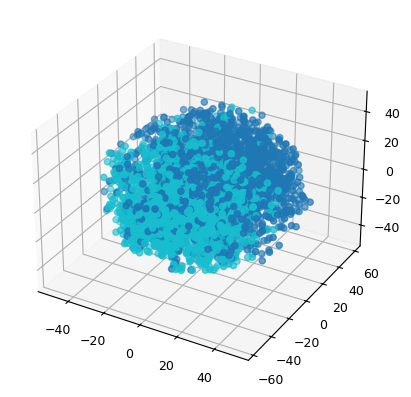

In [15]:
fig, ax = fma.plotting.makeFigure(projection='3d')
ax[0].scatter(pca[::10,1],pca[::10,0],pca[::10,2],c=is_isa[::10],cmap='tab10');